In [1]:
#Itay Toledo
#318720604

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pygal
from pygal.style import Style

In [2]:
#database shows weather parameteres in different weather stations in the US and in Canada
csv="https://courses.cs.washington.edu/courses/cse442/18au/data/weather.csv.gz"
df=pd.read_csv(csv)
copy=df.copy()

In [3]:
##PREPROCCESING
#Convert dates to proper format
copy.date=pd.to_datetime(copy.date, errors='coerce', yearfirst=True, format='%Y%m%d')
# Convert miles per hour to kilometers per hour     
def mph_to_kmph(mph): 
    kmph =mph * 1.60934
    return kmph 
#Convert Fahrenheit to Celsius
def f_to_c(fahr): 
    celsius = (fahr - 32) * (5 / 9)
    return celsius
#Convert miles to kilometers
def inch_to_m(inch):
    m = inch * 39.37
    return m

copy.AWND=mph_to_kmph(copy.AWND)
copy.WSF5=mph_to_kmph(copy.WSF5)

copy.TAVG=f_to_c(copy.TAVG)
copy.TMAX=f_to_c(copy.TMAX)
copy.TMIN=f_to_c(copy.TMIN)

copy.SNOW=inch_to_m(copy.SNOW)
copy.PRCP=inch_to_m(copy.PRCP)
copy.SNWD=inch_to_m(copy.SNWD)
#because of more than 50% null values, I drop this column
copy=copy.drop('SNOW', axis=1)

In [4]:
copy

,station,state,latitude,longitude,elevation,date,TMIN,TMAX,TAVG,AWND,WDF5,WSF5,SNWD,PRCP,seconds
0,GUAM INTL AP,GU,13.4836,144.7961,77.4,2017-03-12,21.7,30.6,26.7,7.199994,360.0,33.839972,0.000000,0.000000,20170312
1,ROOSEVELT ROADS,PR,18.2550,-65.6408,10.1,2017-04-04,25.0,30.0,NaN,14.399988,360.0,37.079969,NaN,0.000000,20170404
2,ROOSEVELT ROADS,PR,18.2550,-65.6408,10.1,2017-04-20,NaN,NaN,NaN,13.679989,360.0,35.279971,NaN,0.000000,20170420
3,SAN JUAN L M MARIN AP,PR,18.4325,-66.0108,2.7,2017-01-20,20.6,27.8,NaN,5.399996,360.0,27.359977,0.000000,0.000000,20170120
4,SAN JUAN L M MARIN AP,PR,18.4325,-66.0108,2.7,2017-02-17,22.8,30.6,NaN,7.559994,360.0,32.039973,0.000000,0.000000,20170217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416932,LAMONI MUNI AP,IA,40.6331,-93.9019,344.7,2017-02-21,5.0,20.6,NaN,11.159991,NaN,NaN,NaN,0.000000,20170221
416933,SISSETON MUNI AP,SD,45.6689,-96.9914,353.9,2017-01-02,-8.8,-3.2,NaN,14.399988,NaN,NaN,124.000067,12.245007,20170102
416934,BOSCOBEL AP,WI,43.1561,-90.6775,204.8,2017-06-06,7.8,27.2,NaN,4.679996,NaN,NaN,0.000000,0.000000,20170606
416935,CHRISTIANSTED AP,VI,17.7028,-64.8056,18.6,2017-09-14,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,20170914


In [5]:
copy.describe()

,latitude,longitude,elevation,TMIN,TMAX,TAVG,AWND,WDF5,WSF5,SNWD,PRCP,seconds
count,416937.000000,416937.000000,416937.000000,415593.000000,415664.000000,259038.000000,234880.000000,226115.000000,226175.000000,312442.000000,414965.000000,4.169370e+05
mean,41.293931,-104.599374,1148.669856,5.439328,17.111712,8.633998,13.103296,202.023612,39.929933,593.277706,4.437398,2.017050e+07
std,7.003117,20.440668,1072.908538,10.514652,11.700558,10.332719,10.858130,98.377489,14.426457,1118.539082,12.940741,2.494075e+02
min,13.483600,-170.222200,-36.000000,-99.900000,-99.900000,-99.900000,0.000000,2.000000,6.479995,0.000000,0.000000,2.017010e+07
25%,37.610000,-116.450000,162.800000,-1.300000,8.200000,1.300000,7.919993,130.000000,29.159976,0.000000,0.000000,2.017031e+07
50%,41.254400,-109.240000,789.400000,6.100000,18.900000,9.300000,11.159991,210.000000,37.079969,0.000000,0.000000,2.017051e+07
75%,44.866400,-90.251100,2130.600000,12.800000,26.500000,16.300000,16.199987,290.000000,48.239960,866.450468,3.875002,2.017072e+07
max,71.283300,145.716700,3541.800000,37.200000,127.600000,49.200000,181.079850,360.000000,289.799760,11023.605953,1024.860553,2.017092e+07


In [6]:
copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416937 entries, 0 to 416936
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   station    416937 non-null  object        
 1   state      416937 non-null  object        
 2   latitude   416937 non-null  float64       
 3   longitude  416937 non-null  float64       
 4   elevation  416937 non-null  float64       
 5   date       416937 non-null  datetime64[ns]
 6   TMIN       415593 non-null  float64       
 7   TMAX       415664 non-null  float64       
 8   TAVG       259038 non-null  float64       
 9   AWND       234880 non-null  float64       
 10  WDF5       226115 non-null  float64       
 11  WSF5       226175 non-null  float64       
 12  SNWD       312442 non-null  float64       
 13  PRCP       414965 non-null  float64       
 14  seconds    416937 non-null  int64         
dtypes: datetime64[ns](1), float64(11), int64(1), object(2)
memory usage:

In [7]:
#For pygal plots
from IPython.display import display, HTML
base_html = """
<!DOCTYPE html>
<html>
  <head>
  <script type="text/javascript" src="http://kozea.github.com/pygal.js/javascripts/svg.jquery.js"></script>
  <script type="text/javascript" src="https://kozea.github.io/pygal.js/2.0.x/pygal-tooltips.min.js""></script>
  </head>
  <body>
    <figure>
      {rendered_chart}
    </figure>
  </body>
</html>
"""

In [1]:
#Enlarging figure size
matplotlib.rc('figure', figsize=(15, 9))

NameError: name 'matplotlib' is not defined

In [9]:
#Plot 1
measures_per_state = copy.state.value_counts()
bar_chart = pygal.Bar(height=400)
bar_chart.title='Number of measures in every state'
[bar_chart.add(x[0], x[1]) for x in measures_per_state.items()]
display(HTML(base_html.format(rendered_chart=bar_chart.render(is_unicode=True))))



In [10]:
#Plot 2
measures_per_station= copy.sort_values(by=['station'],ascending=False).groupby(['station']).size()
pie_chart=pygal.Pie(height=400, truncate_legend=23)
pie_chart.title='Number of measures in every station'
first100 = list(measures_per_station.items())[:100]
[pie_chart.add(x[0], x[1]) for x in first100]
display(HTML(base_html.format(rendered_chart=pie_chart.render(is_unicode=True))))

Text(0.5, 1.0, 'Average temperatures by measurement date')

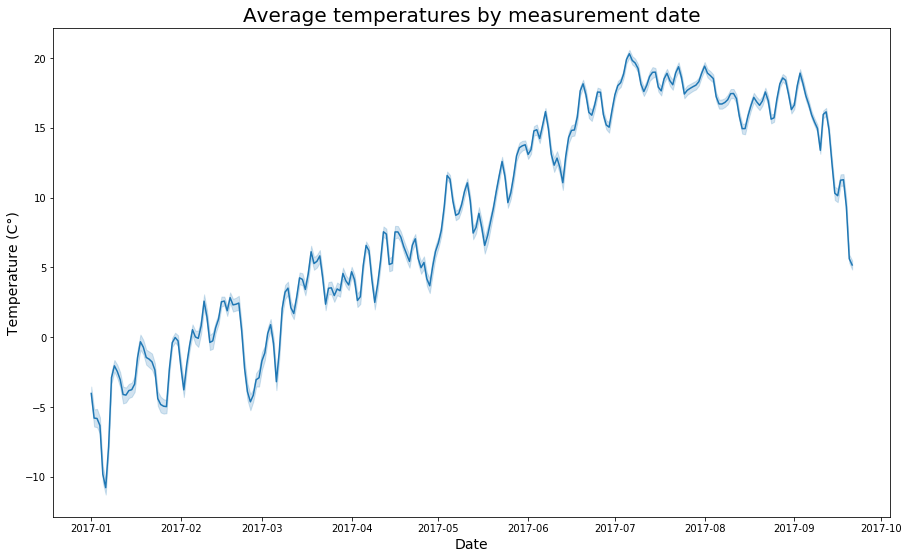

In [26]:
#Plot 3
sns.lineplot(x='date', y='TAVG', data=copy, palette='black')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Temperature (C°)', fontsize=14)
plt.title('Average temperatures by measurement date', fontsize=20)

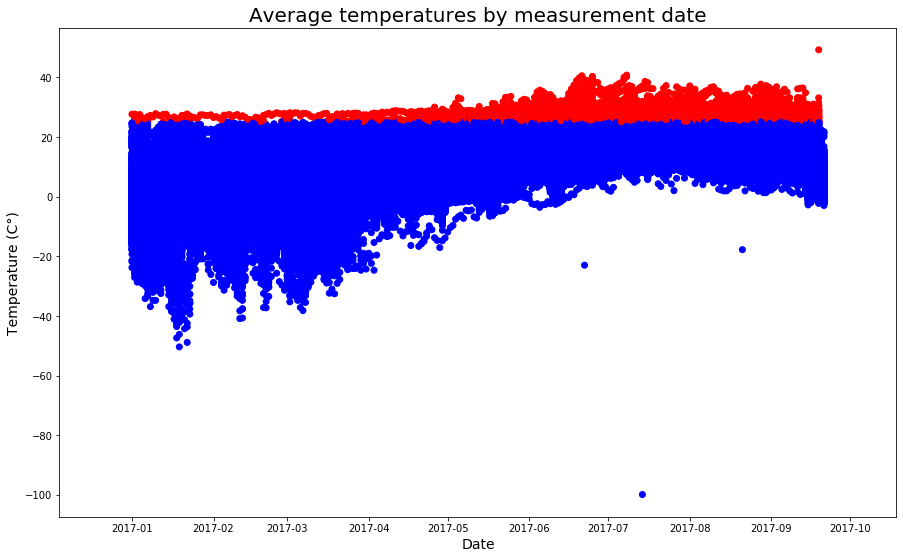

In [17]:
#Plot 4
plt.xlabel('Date', fontsize=14)
plt.ylabel('Temperature (C°)', fontsize=14)
plt.title('Average temperatures by measurement date', fontsize=20)
color=['red' if t > 25 else 'blue' for t in copy.TAVG ]
plt.scatter(x=copy.date, y=copy.TAVG, color=color)
plt.show()

In [13]:
#Plot 5
NorthEast = len([d for d in copy.WDF5 if d > 0 and d <= 90 ])
NorthWest = len([d for d in copy.WDF5 if d > 90 and d <= 180])
SouthWest = len([d for d in copy.WDF5 if d > 180 and d <= 270])
SouthEast = len([d for d in copy.WDF5 if d > 270 and d <= 0])
custom_style = Style(
  background='transparent',
  plot_background='transparent',
  foreground_strong='#53A0E8',
  foreground_subtle='#630C0D',
  transition='400ms ease-in',
  colors=('#E853B0', '#E8507A', '#E95355', '#E87653', '#E89B53'))
chart = pygal.Pie(height=350, style=custom_style, truncate_legend=30)
chart.title = 'Direction of fastest 5-seconds wind'
chart.add('North East ({})'.format(NorthEast), NorthEast)
chart.add('North West ({})'.format(NorthWest), NorthWest)
chart.add('South West ({})'.format(SouthWest), SouthWest)
chart.add('South East ({})'.format(SouthEast), SouthEast)
display(HTML(base_html.format(rendered_chart=chart.render(is_unicode=True))))

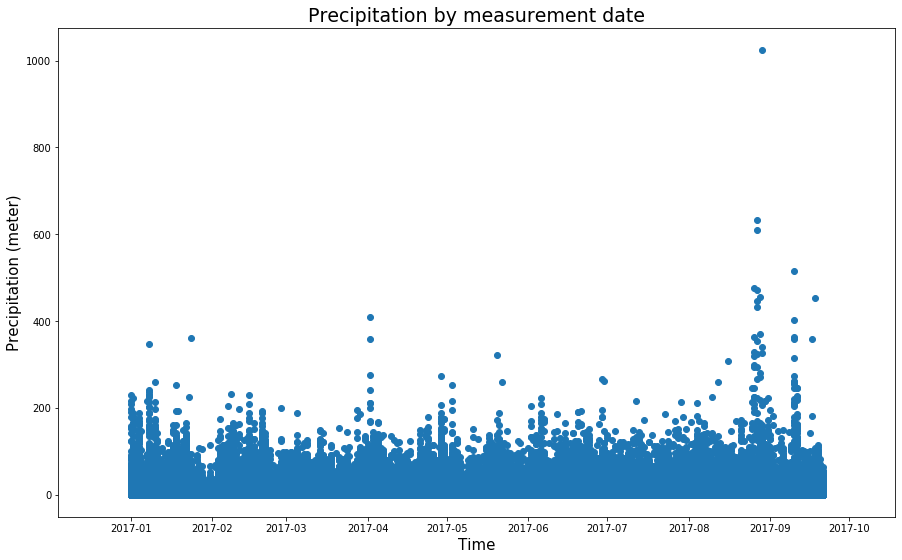

In [14]:
#Plot 6
plt.scatter(x=copy.date, y=copy.PRCP)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Precipitation (meter)', fontsize=15)
plt.title('Precipitation by measurement date', fontsize=19)
plt.show()

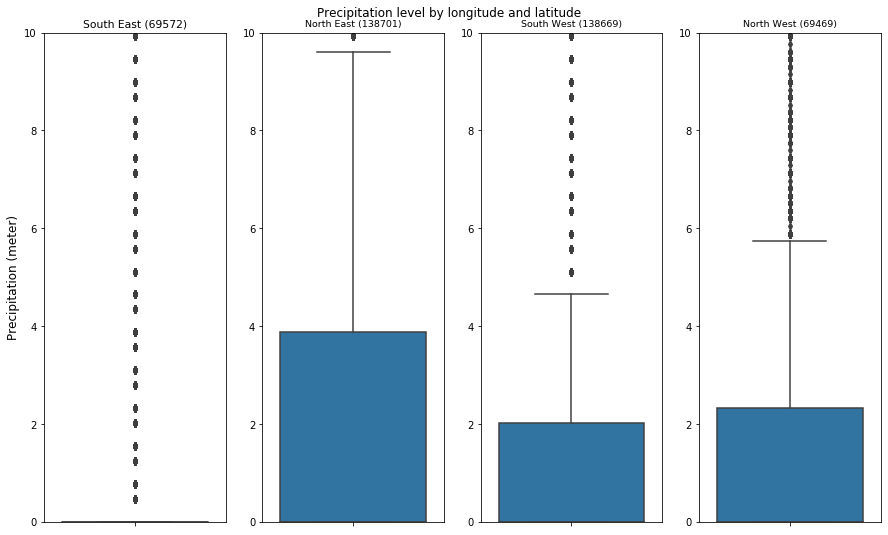

In [15]:
#Plot 7
LTmedian=copy.latitude.median()
LGmedian=copy.longitude.median()
East_South= copy.query('latitude < @LTmedian and longitude < @LGmedian', inplace=False)
East_North= copy.query('latitude > @LTmedian and longitude < @LGmedian', inplace=False)
West_South= copy.query('latitude < @LTmedian and longitude > @LGmedian', inplace=False)
West_North= copy.query('latitude > @LTmedian and longitude > @LGmedian', inplace=False)
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1, 4)
fig.suptitle('Precipitation level by longitude and latitude', fontsize=12, y=0.92)

sns.boxplot(y='PRCP', data=East_South, ax=ax1)
ax1.set_title('South East ({})'.format(len(East_South)), fontsize=10.8)
ax1.set_ylim(bottom=0, top = 10)
ax1.set_ylabel('Precipitation (meter)', fontsize=12)

sns.boxplot(y='PRCP', data=East_North, ax=ax2)
ax2.set_title('North East ({})'.format(len(East_North)), fontsize=9.5)
ax2.set_ylim(bottom=0, top = 10)
ax2.set_ylabel('')

sns.boxplot(y='PRCP', data=West_South, ax=ax3)
ax3.set_title('South West ({})'.format(len(West_South)), fontsize=9.5)
ax3.set_ylim(bottom=0, top = 10)
ax3.set_ylabel('')

sns.boxplot(y='PRCP', data=West_North, ax=ax4)
ax4.set_title('North West ({})'.format(len(West_North)), fontsize=9.5)
ax4.set_ylim(bottom=0, top = 10)
ax4.set_ylabel('')

plt.show()

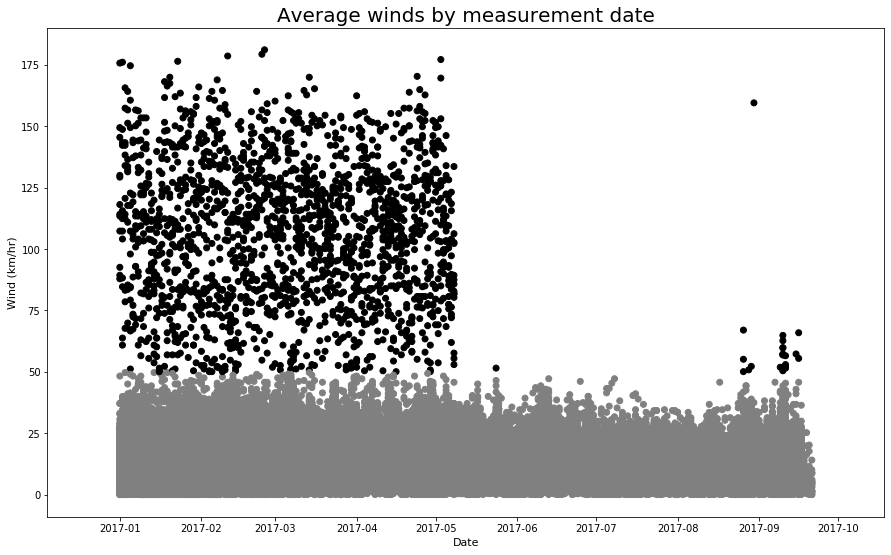

In [16]:
#Plot 8
plt.xlabel('Date', fontsize=11)
plt.ylabel('Wind (km/hr)', fontsize=11)
plt.title('Average winds by measurement date', fontsize=20)
color=['black' if w > 50 else 'grey' for w in copy.AWND ]
plt.scatter(x=copy.date, y=copy.AWND, color = color)

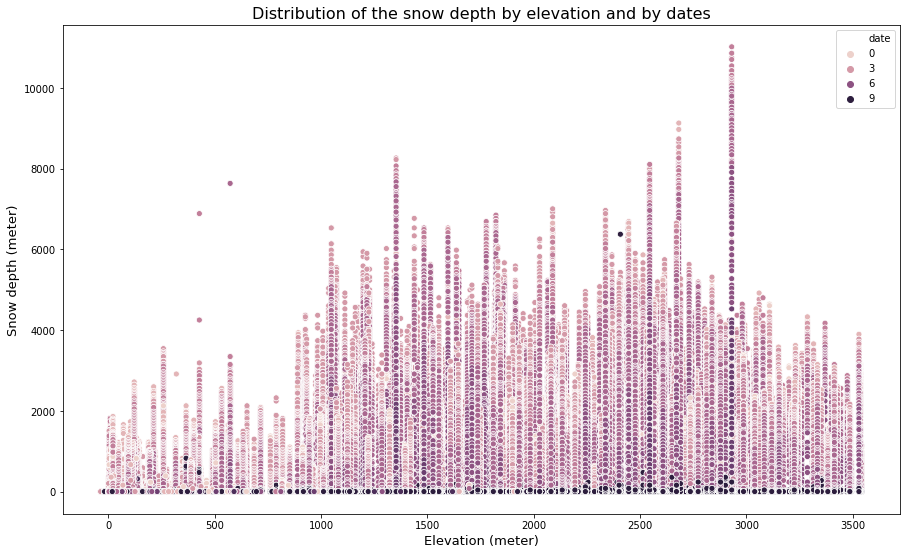

In [17]:
#Plot 9
sns.scatterplot(x='elevation', y='SNWD', data=copy, hue=pd.DatetimeIndex(copy['date']).month, legend='brief')
plt.title('Distribution of the snow depth by elevation and by dates', fontsize=16)
plt.ylabel('Snow depth (meter)', fontsize=13)
plt.xlabel('Elevation (meter)', fontsize=13)
plt.show()

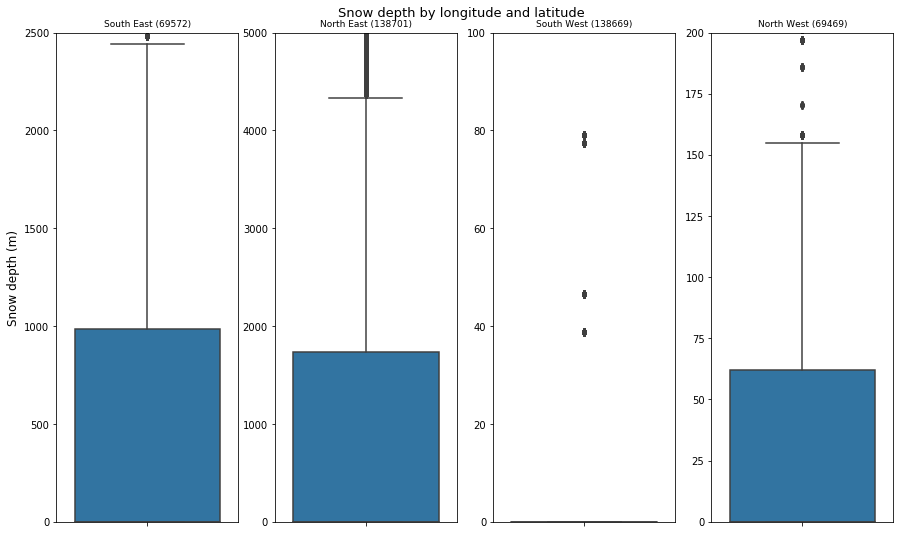

In [18]:
#Plot 10
LTmedian=copy.latitude.median()
LGmedian=copy.longitude.median()
East_South= copy.query('latitude < @LTmedian and longitude < @LGmedian', inplace=False)
East_North= copy.query('latitude > @LTmedian and longitude < @LGmedian', inplace=False)
West_South= copy.query('latitude < @LTmedian and longitude > @LGmedian', inplace=False)
West_North= copy.query('latitude > @LTmedian and longitude > @LGmedian', inplace=False)
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1, 4)
fig.suptitle('Snow depth by longitude and latitude', fontsize=13, y=0.92)

sns.boxplot(y='SNWD', data=East_South, ax=ax1)
ax1.set_title('South East ({})'.format(len(East_South)), fontsize=9)
ax1.set_ylim(bottom=0, top = 2500)
ax1.set_ylabel('Snow depth (m)', fontsize=12)

sns.boxplot(y='SNWD', data=East_North, ax=ax2)
ax2.set_title('North East ({})'.format(len(East_North)), fontsize=9)
ax2.set_ylim(bottom=0, top = 5000)
ax2.set_ylabel('')

sns.boxplot(y='SNWD', data=West_South, ax=ax3)
ax3.set_title('South West ({})'.format(len(West_South)), fontsize=9)
ax3.set_ylim(bottom=0, top = 100)
ax3.set_ylabel('')

sns.boxplot(y='SNWD', data=West_North, ax=ax4)
ax4.set_title('North West ({})'.format(len(West_North)), fontsize=9)
ax4.set_ylim(bottom=0, top = 200)
ax4.set_ylabel('')

plt.show()

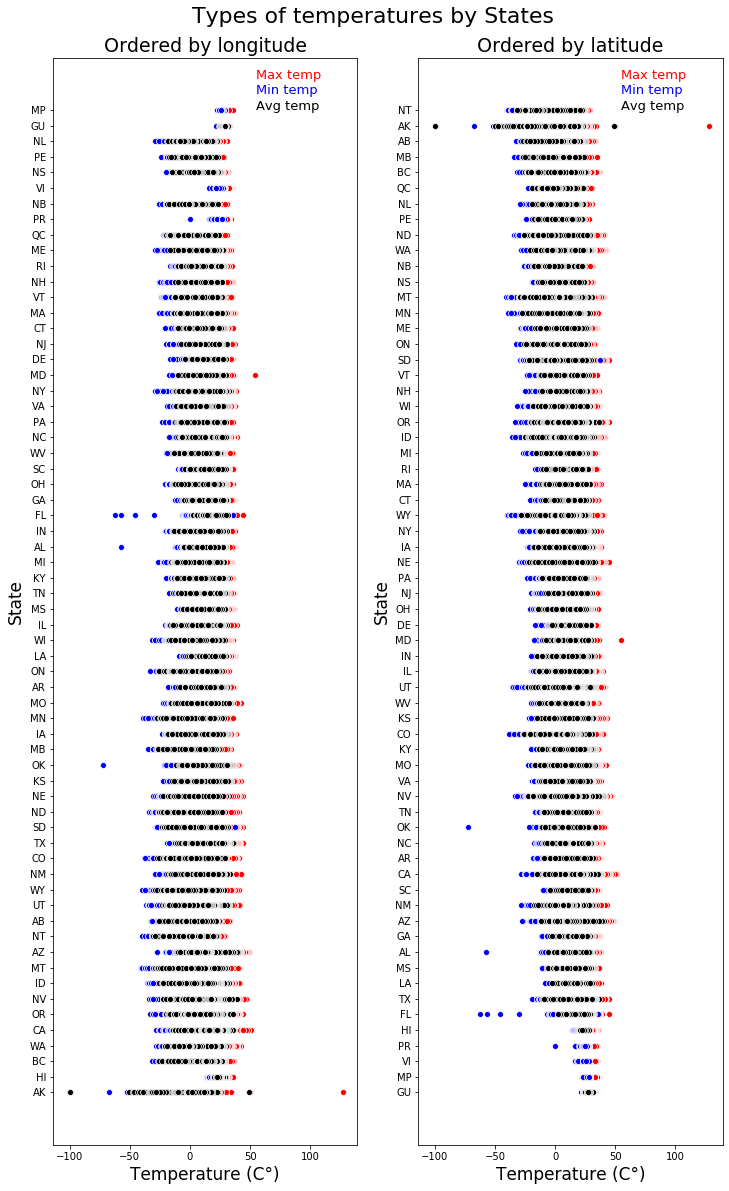

In [32]:
#Plot 11
fig, (long, lat) = plt.subplots(1,2)
sorted_lg=copy.sort_values(by=['longitude'], ascending=[True]) 
sns.scatterplot(y=sorted_lg.state, x=sorted_lg.TMAX, color='red', ax=long)
sns.scatterplot(y=sorted_lg.state, x=sorted_lg.TMIN, color='blue', ax=long)
sns.scatterplot(y=sorted_lg.state, x=sorted_lg.TAVG, color='black', ax=long)
fig.suptitle('Types of temperatures by States ', fontsize=22, y=0.915)
long.set_ylabel('State', fontsize=17)
long.set_xlabel('Temperature (C°)', fontsize=17)
long.set_title('Ordered by longitude', fontsize=19)
long.text(x=55, y=65, s='Max temp', color='red', fontsize=13)
long.text(x=55, y=64, s='Min temp', color='blue', fontsize=13)
long.text(x=55, y=63, s='Avg temp', color='black', fontsize=13)

sorted_lt=copy.sort_values(by=['latitude'], ascending=[True]) 
sns.scatterplot(y=sorted_lt.state, x=sorted_lt.TMAX, color='red', ax=lat)
sns.scatterplot(y=sorted_lt.state, x=sorted_lt.TMIN, color='blue', ax=lat)
sns.scatterplot(y=sorted_lt.state, x=sorted_lt.TAVG, color='black', ax=lat)
lat.set_ylabel('State', fontsize=17)
lat.set_xlabel('Temperature (C°)', fontsize=17)
lat.set_title('Ordered by latitude', fontsize=19)
lat.text(x=55, y=65, s='Max temp', color='red', fontsize=13)
lat.text(x=55, y=64, s='Min temp', color='blue', fontsize=13)
lat.text(x=55, y=63, s='Avg temp', color='black', fontsize=13)

#Enlarging figure size
matplotlib.rc('figure', figsize=(12, 20))
plt.show()